In [93]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [2]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
epochs=20, batch_size=128, extra_callbacks=None):

    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
    validation_data=(x_v, to_categorical(y_v, 10)),
    epochs=epochs, batch_size=batch_size,
    callbacks=cb, verbose=0)

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

In [3]:
def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 1A


In [4]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
x_train_A = x_train
x_val_A = x_val
x_test_A = x_test

x_train_B = x_train / 255.0
x_val_B = x_val / 255.0
x_test_B = x_test / 255.0


mean = np.mean(x_train, axis=(0,1,2))
std = np.std(x_train, axis=(0,1,2))

x_train_C = (x_train - mean) / std
x_val_C = (x_val - mean) / std
x_test_C = (x_test - mean) / std

In [6]:
model_A = build_baseline_cnn()
history_A, acc_A, loss_A, time_A = train_and_evaluate(
    model_A, x_train_A, y_train, x_val_A, y_val, x_test_A, y_test
)

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5428 | Test Loss: 2.7252 | Time: 125.6s


In [7]:
model_B = build_baseline_cnn()
history_B, acc_B, loss_B, time_B = train_and_evaluate(
    model_B, x_train_B, y_train, x_val_B, y_val, x_test_B, y_test
)

Test Acc: 0.6721 | Test Loss: 1.2329 | Time: 126.3s


In [8]:
model_C = build_baseline_cnn()
history_C, acc_C, loss_C, time_C = train_and_evaluate(
    model_C, x_train_C, y_train, x_val_C, y_val, x_test_C, y_test
)

Test Acc: 0.6752 | Test Loss: 2.1720 | Time: 125.9s


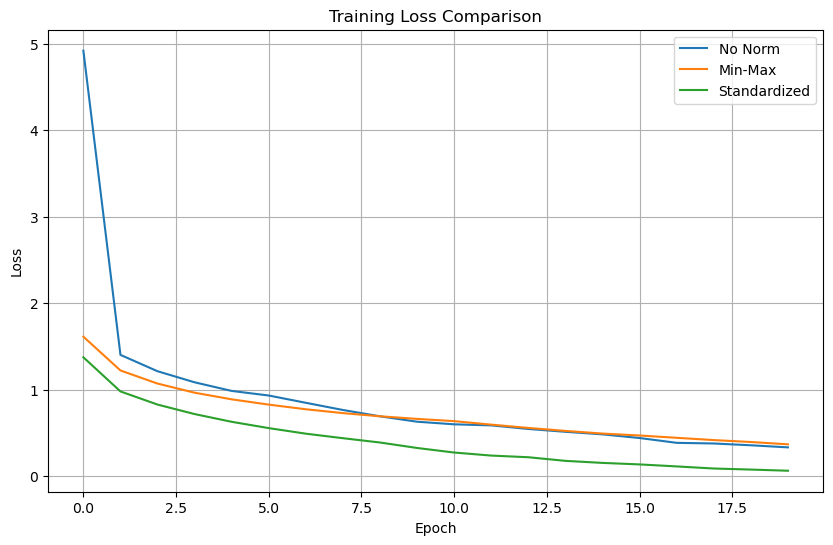

In [9]:
plot_curves(
    [history_A, history_B, history_C],
    ['No Norm', 'Min-Max', 'Standardized'],
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)

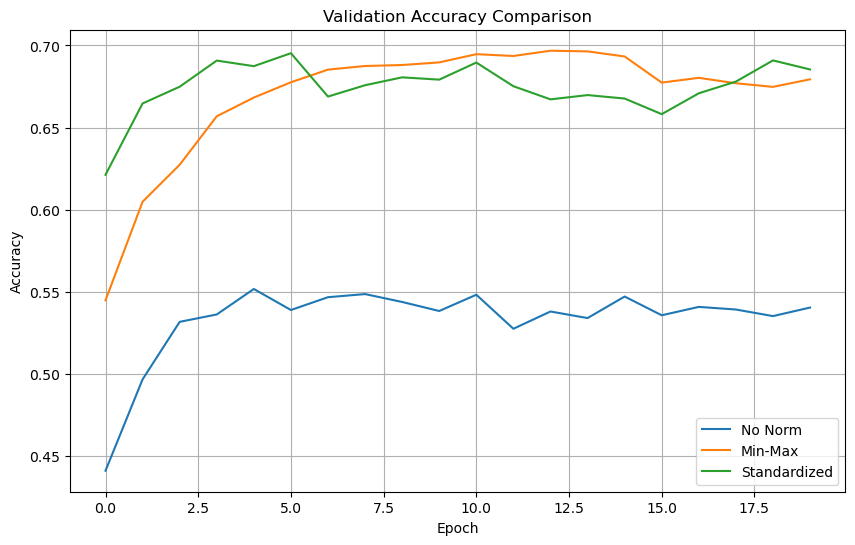

In [10]:
plot_curves(
    [history_A, history_B, history_C],
    ['No Norm', 'Min-Max', 'Standardized'],
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

In [11]:
train_acc_A = history_A.history['accuracy'][-1]
val_acc_A = history_A.history['val_accuracy'][-1]
test_acc_A = acc_A

train_acc_B = history_B.history['accuracy'][-1]
val_acc_B = history_B.history['val_accuracy'][-1]
test_acc_B = acc_B

train_acc_C = history_C.history['accuracy'][-1]
val_acc_C = history_C.history['val_accuracy'][-1]
test_acc_C = acc_C

In [12]:
import pandas as pd

results = pd.DataFrame({
    "Preprocessing": ["None", "Min-Max", "Standardized"],
    "Train Acc": [train_acc_A, train_acc_B, train_acc_C],
    "Val Acc": [val_acc_A, val_acc_B, val_acc_C],
    "Test Acc": [test_acc_A, test_acc_B, test_acc_C],
})

print(results)

  Preprocessing  Train Acc  Val Acc  Test Acc
0          None   0.884625   0.5405    0.5428
1       Min-Max   0.873825   0.6794    0.6721
2  Standardized   0.979925   0.6854    0.6752


# **1B**

In [13]:
model_no_aug = build_baseline_cnn()

history_no_aug, acc_no_aug, loss_no_aug, time_no_aug = train_and_evaluate(
    model_no_aug,
    x_train_C, y_train,
    x_val_C, y_val,
    x_test_C, y_test,
    epochs=40,
    batch_size=128
)

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6718 | Test Loss: 3.3463 | Time: 247.5s


In [14]:
import tensorflow as tf

In [15]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_C)

In [16]:
model_aug = build_baseline_cnn()

start = time.time()

history_aug = model_aug.fit(
    datagen.flow(x_train_C, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_C, to_categorical(y_val, 10)),
    epochs=40,
    verbose=0
)

elapsed_aug = time.time() - start

test_loss_aug, test_acc_aug = model_aug.evaluate(
    x_test_C, to_categorical(y_test, 10), verbose=0
)

print(f"Test Acc: {test_acc_aug:.4f} | Time: {elapsed_aug:.1f}s")

Test Acc: 0.7590 | Time: 773.2s


In [17]:
model_aug = build_baseline_cnn()

start = time.time()

history_aug = model_aug.fit(
    datagen.flow(x_train_C, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_C, to_categorical(y_val, 10)),
    epochs=40,
    verbose=0
)

elapsed_aug = time.time() - start

test_loss_aug, test_acc_aug = model_aug.evaluate(
    x_test_C, to_categorical(y_test, 10), verbose=0
)

print(f"Test Acc: {test_acc_aug:.4f} | Time: {elapsed_aug:.1f}s")

Test Acc: 0.7723 | Time: 776.1s


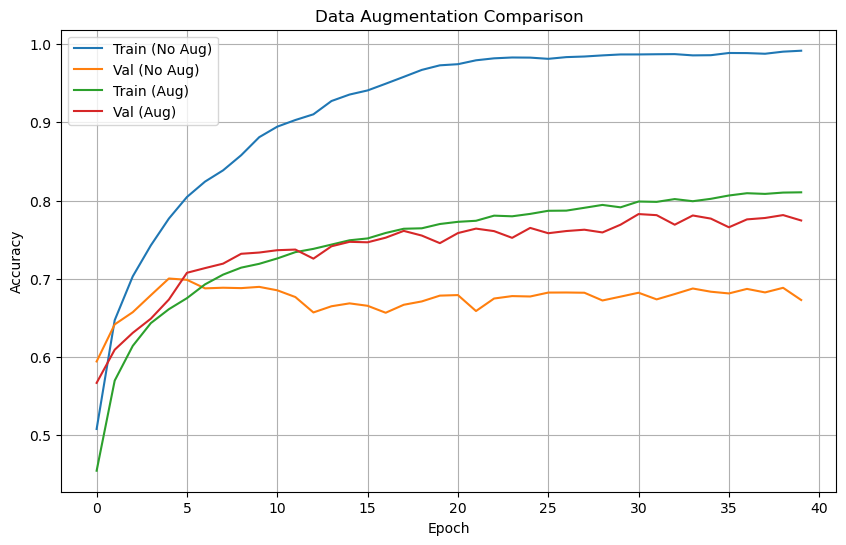

In [18]:
plt.figure(figsize=(10,6))

# no augmentation
plt.plot(history_no_aug.history['accuracy'], label='Train (No Aug)')
plt.plot(history_no_aug.history['val_accuracy'], label='Val (No Aug)')

# with augmentation
plt.plot(history_aug.history['accuracy'], label='Train (Aug)')
plt.plot(history_aug.history['val_accuracy'], label='Val (Aug)')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Data Augmentation Comparison')
plt.legend()
plt.grid(True)
plt.show()

In [19]:

gap_no_aug = (
    history_no_aug.history['accuracy'][-1]
    - history_no_aug.history['val_accuracy'][-1]
)


gap_aug = (
    history_aug.history['accuracy'][-1]
    - history_aug.history['val_accuracy'][-1]
)

print("Gap No Aug:", gap_no_aug)
print("Gap Aug:", gap_aug)

Gap No Aug: 0.3187999725341797
Gap Aug: 0.03602498769760132


Augmentation overfits less

## 2A

In [20]:
# standardize data
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))
x_train_std = (x_train - mean) / std
x_val_std = (x_val - mean) / std
x_test_std = (x_test - mean) / std


print(np.mean(x_train_std))
print(np.std(x_train_std))

4.0611885e-06
1.0000004


In [21]:
def build_cnn_model(f1,f2,f3,f4):

    model = models.Sequential([
        # layer 1
        layers.Conv2D(f1, (3,3), activation='relu',padding='same', input_shape=(32, 32, 3)),

        # layer 2
        layers.Conv2D(f2,(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D((2, 2)),

        # layer 3
        layers.Conv2D(f3,(3,3), activation='relu', padding='same'),

        # layer 4
        layers.Conv2D(f4,(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')

    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']

    )
    return model



models_config = {
    "Small": (8, 8, 16, 16),
    "Medium": (32, 32, 64, 64),
    "Large": (64, 64, 128, 128)
}

histories = []
labels = []
results = []

for name, (f1, f2, f3, f4) in models_config.items():

    print(f"\nTraining {name} model...")

    model = build_cnn_model(f1, f2, f3, f4)

    model.summary()

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )

    histories.append(history)
    labels.append(name)

    results.append({
        "Model": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })



Training Small model...


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,786 (534.32 KB)

 Trainable params: 136,786 (534.32 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,310,154 (5.00 MB)

 Trainable params: 1,310,154 (5.00 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7471 | Test Loss: 1.7810 | Time: 930.7s


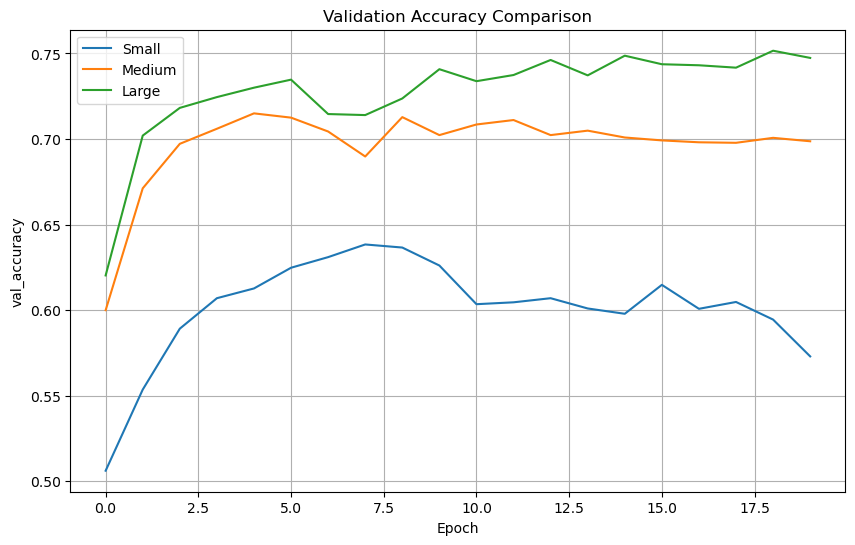

In [22]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy Comparison'
)

**3A**

In [23]:
def build_cnn_dropout(drop_rate=0.0):

    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(drop_rate),

        # Conv Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Dropout(drop_rate),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),

        layers.Dropout(drop_rate),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [24]:
model_D0 = build_cnn_dropout(0.0)
history_D0, acc_D0, loss_D0, t_D0 = train_and_evaluate(
    model_D0, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test,
    epochs=30
)

Test Acc: 0.7121 | Test Loss: 2.6597 | Time: 493.4s


In [25]:
model_D1 = build_cnn_dropout(0.25)
history_D1, acc_D1, loss_D1, t_D1 = train_and_evaluate(
    model_D1, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test,
    epochs=30
)

Test Acc: 0.7761 | Test Loss: 0.8485 | Time: 526.9s


In [26]:
model_D2 = build_cnn_dropout(0.5)
history_D2, acc_D2, loss_D2, t_D2 = train_and_evaluate(
    model_D2, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test,
    epochs=30
)

Test Acc: 0.7877 | Test Loss: 0.6232 | Time: 519.2s


In [27]:
gap_D0 = history_D0.history['accuracy'][-1] - history_D0.history['val_accuracy'][-1]
gap_D1 = history_D1.history['accuracy'][-1] - history_D1.history['val_accuracy'][-1]
gap_D2 = history_D2.history['accuracy'][-1] - history_D2.history['val_accuracy'][-1]

In [28]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["D0", "D1", "D2"],
    "Train Acc": [
        history_D0.history['accuracy'][-1],
        history_D1.history['accuracy'][-1],
        history_D2.history['accuracy'][-1]
    ],
    "Val Acc": [
        history_D0.history['val_accuracy'][-1],
        history_D1.history['val_accuracy'][-1],
        history_D2.history['val_accuracy'][-1]
    ],
    "Test Acc": [acc_D0, acc_D1, acc_D2],
    "Overfit Gap": [gap_D0, gap_D1, gap_D2]
})

print(results)

  Model  Train Acc  Val Acc  Test Acc  Overfit Gap
0    D0     0.9896   0.7196    0.7121       0.2700
1    D1     0.9279   0.7855    0.7761       0.1424
2    D2     0.7871   0.7928    0.7877      -0.0057


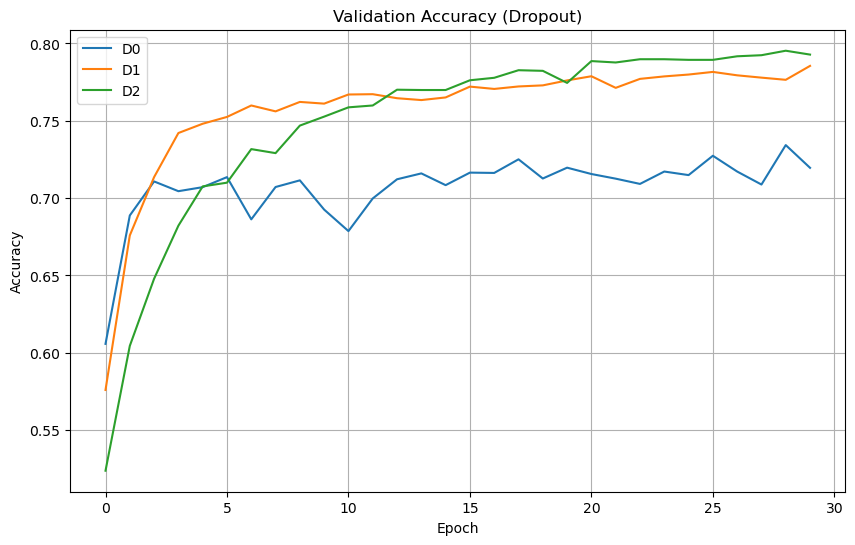

In [29]:
plot_curves(
    [history_D0, history_D1, history_D2],
    ['D0', 'D1', 'D2'],
    metric='val_accuracy',
    title='Validation Accuracy (Dropout)',
    ylabel='Accuracy'
)

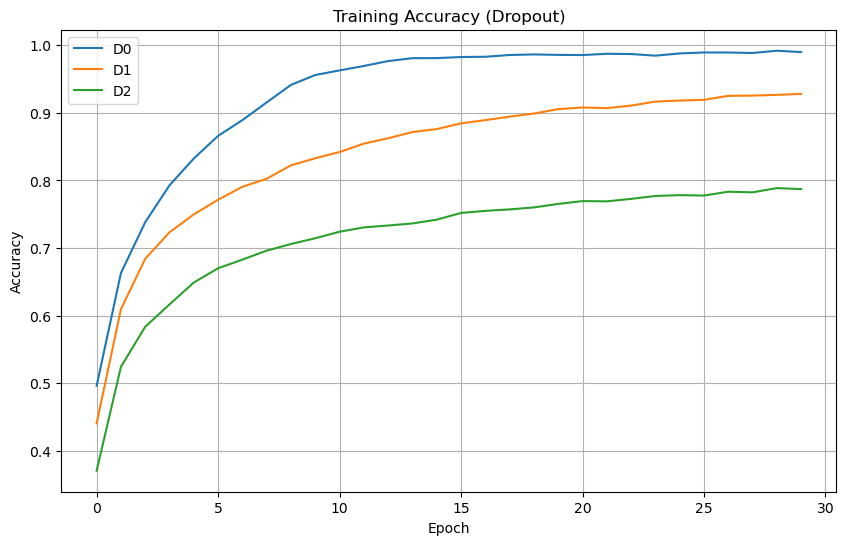

In [30]:
plot_curves(
    [history_D0, history_D1, history_D2],
    ['D0', 'D1', 'D2'],
    metric='accuracy',
    title='Training Accuracy (Dropout)',
    ylabel='Accuracy'
)

# **3B**

In [31]:
model = build_cnn_dropout(0.0)

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model_ES0 = build_cnn_dropout(0.0)

history_ES0, acc_ES0, loss_ES0, time_ES0 = train_and_evaluate(
    model_ES0,
    x_train_std, y_train,
    x_val_std, y_val,
    x_test_std, y_test,
    epochs=50
)

Test Acc: 0.7194 | Test Loss: 3.1916 | Time: 832.5s


In [33]:
es2 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [34]:
model_ES2 = build_cnn_dropout(0.0)

history_ES2, acc_ES2, loss_ES2, time_ES2 = train_and_evaluate(
    model_ES2,
    x_train_std, y_train,
    x_val_std, y_val,
    x_test_std, y_test,
    epochs=50,
    extra_callbacks=[es2]
)

Test Acc: 0.7009 | Test Loss: 0.8827 | Time: 133.2s


In [35]:
es3 = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)



model_ES3 = build_cnn_dropout(0.0)

history_ES3, acc_ES3, loss_ES3, time_ES3 = train_and_evaluate(
    model_ES3,
    x_train_std, y_train,
    x_val_std, y_val,
    x_test_std, y_test,
    epochs=50,
    extra_callbacks=[es3]
)

Test Acc: 0.7169 | Test Loss: 0.8461 | Time: 232.1s


In [36]:
stopped_ES2 = len(history_ES2.history['loss'])
stopped_ES3 = len(history_ES3.history['loss'])


best_val_loss_ES0 = min(history_ES0.history['val_loss'])
best_val_loss_ES2 = min(history_ES2.history['val_loss'])
best_val_loss_ES3 = min(history_ES3.history['val_loss'])

In [37]:
import pandas as pd

results = pd.DataFrame({
    "Experiment": ["ES0", "ES2", "ES3"],
    "Stopped Epoch": [50, stopped_ES2, stopped_ES3],
    "Best Val Loss": [best_val_loss_ES0, best_val_loss_ES2, best_val_loss_ES3],
    "Test Acc": [acc_ES0, acc_ES2, acc_ES3],
    "Time": [time_ES0, time_ES2, time_ES3]
})

print(results)

  Experiment  Stopped Epoch  Best Val Loss  Test Acc        Time
0        ES0             50       0.800319    0.7194  832.485980
1        ES2              8       0.863310    0.7009  133.194871
2        ES3             14       0.831441    0.7169  232.106383


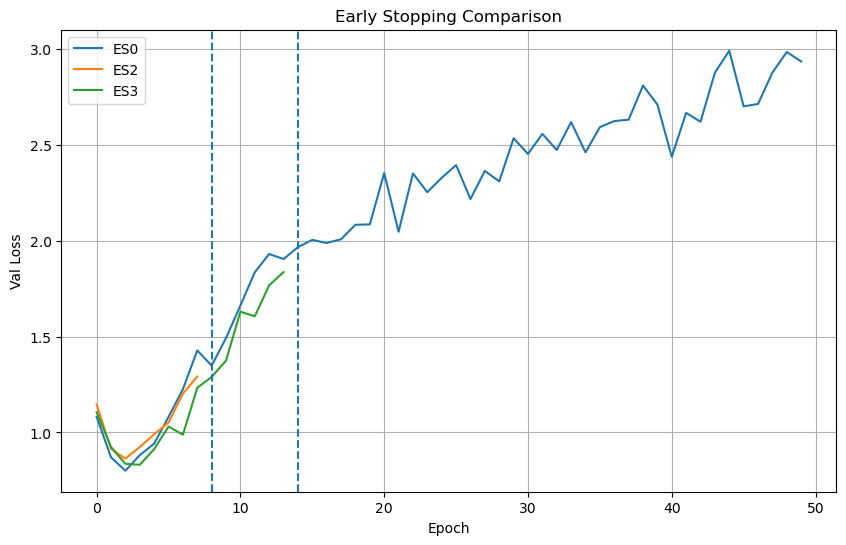

In [38]:
plt.figure(figsize=(10,6))

plt.plot(history_ES0.history['val_loss'], label='ES0')
plt.plot(history_ES2.history['val_loss'], label='ES2')
plt.plot(history_ES3.history['val_loss'], label='ES3')

# vertical lines
plt.axvline(x=stopped_ES2, linestyle='--')
plt.axvline(x=stopped_ES3, linestyle='--')

plt.xlabel('Epoch')
plt.ylabel('Val Loss')
plt.title('Early Stopping Comparison')
plt.legend()
plt.grid(True)
plt.show()

Is patience=5 too aggressive? Is patience=10 too lenient?

Patience = 5 can be considered slightly aggressive, as it may stop training too early before the model has fully converged, especially if the validation loss fluctuates temporarily.

On the other hand, patience = 10 is more lenient, as it allows the model to continue training for a longer time. This can help achieve better performance, but it may also increase the risk of overfitting if the model continues training after reaching its optimal point.

## 2C

In [39]:
def build_shallow():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def build_medium_depth():
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

def build_deep():
    model = models.Sequential([

        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),

        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(0.001),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model

In [40]:
models_dict = {
    "Shallow": build_shallow(),
    "Medium": build_medium_depth(),
    "Deep": build_deep()
}

histories = {}
results = []

for name, model in models_dict.items():

    print(f"\nTraining {name} model...")

    model.summary()

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )

    histories[name] = history

    results.append({
        "Model": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })


Training Shallow model...


c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,754 (2.12 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_36 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_65 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_37 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_66 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_67 (Conv2D)              │ (None, 8, 8, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_38 (MaxPooling2D) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_68 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_69 (Conv2D)              │ (None, 4, 4, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7216 | Test Loss: 0.8702 | Time: 244.5s


In [41]:
import pandas as pd

In [42]:
df = pd.DataFrame(results)
print(df)

     Model  Test Acc  Test Loss        Time
0  Shallow    0.6935   2.421664  236.637814
1   Medium    0.7420   0.752510  237.415962
2     Deep    0.7216   0.870236  244.478129


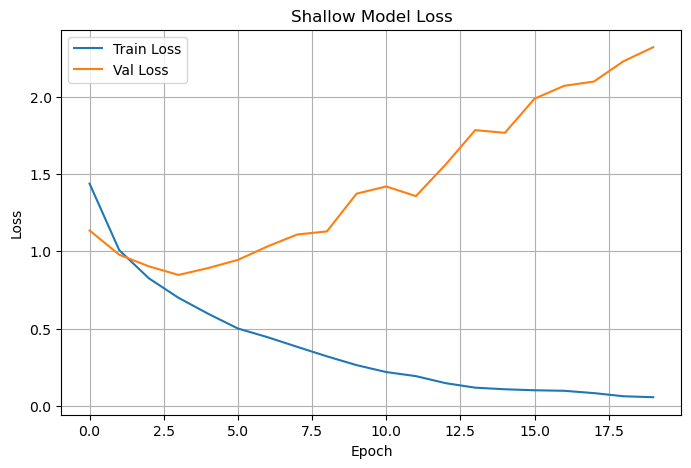

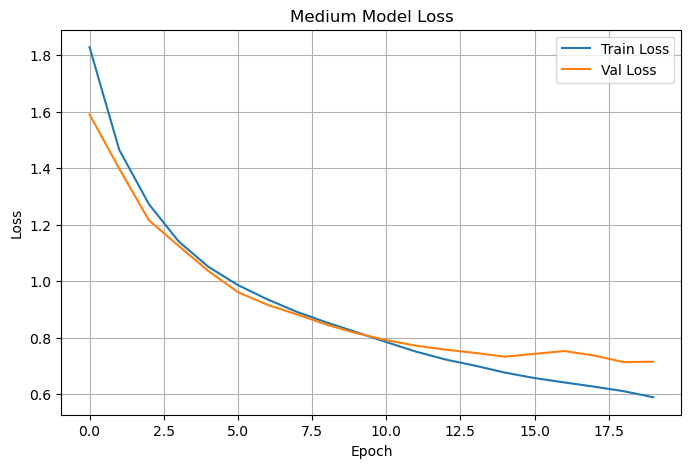

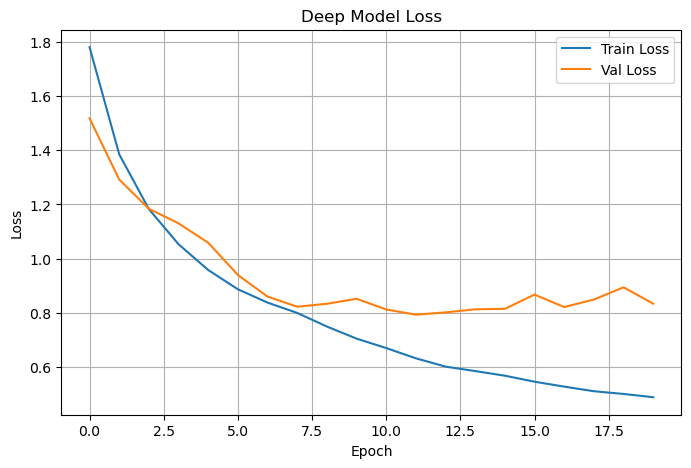

In [43]:
for name, history in histories.items():

    plt.figure(figsize=(8,5))

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')

    plt.title(f'{name} Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.show()

## 4A

In [44]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001),
}

def build_medium_model():
    return build_cnn_model(32, 32, 64, 64)

histories = []
labels = []
results = []

for name, opt in optimizers.items():

    print(f"\nTraining with {name} optimizer...")

    model = build_medium_model()
    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test
    )

    histories.append(history)
    labels.append(name)

    results.append({
        "Optimizer": name,
        "Test Acc": test_acc,
        "Test Loss": test_loss,
        "Time": t
    })




Training with SGD optimizer...


c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.4689 | Test Loss: 1.4931 | Time: 305.1s

Training with Momentum optimizer...
Test Acc: 0.6823 | Test Loss: 0.9502 | Time: 306.4s

Training with AdaGrad optimizer...
Test Acc: 0.5241 | Test Loss: 1.3466 | Time: 307.5s

Training with RMSProp optimizer...
Test Acc: 0.7187 | Test Loss: 2.6040 | Time: 308.9s

Training with Adam optimizer...
Test Acc: 0.7201 | Test Loss: 2.0908 | Time: 309.8s


In [45]:
df = pd.DataFrame(results)
print(df)

  Optimizer  Test Acc  Test Loss        Time
0       SGD    0.4689   1.493146  305.054161
1  Momentum    0.6823   0.950211  306.398978
2   AdaGrad    0.5241   1.346587  307.454973
3   RMSProp    0.7187   2.603991  308.904469
4      Adam    0.7201   2.090785  309.786943


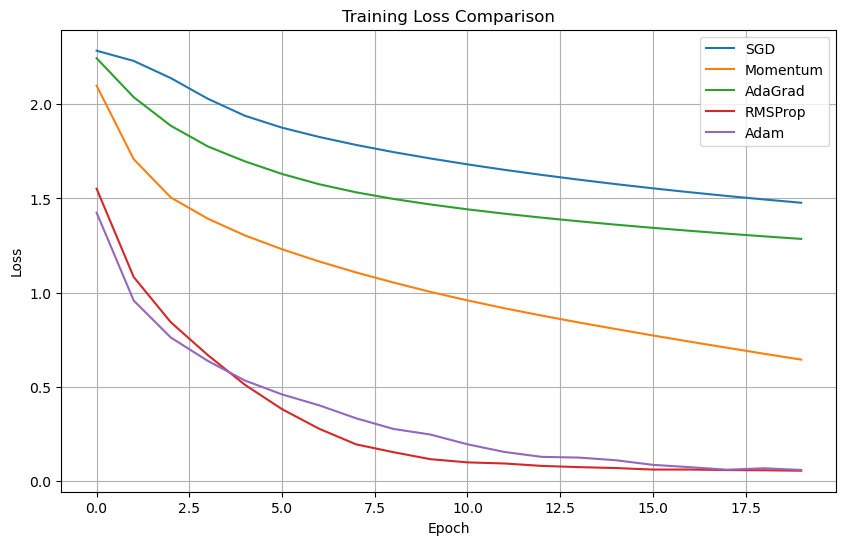

In [46]:
plot_curves(
    histories,
    labels,
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)

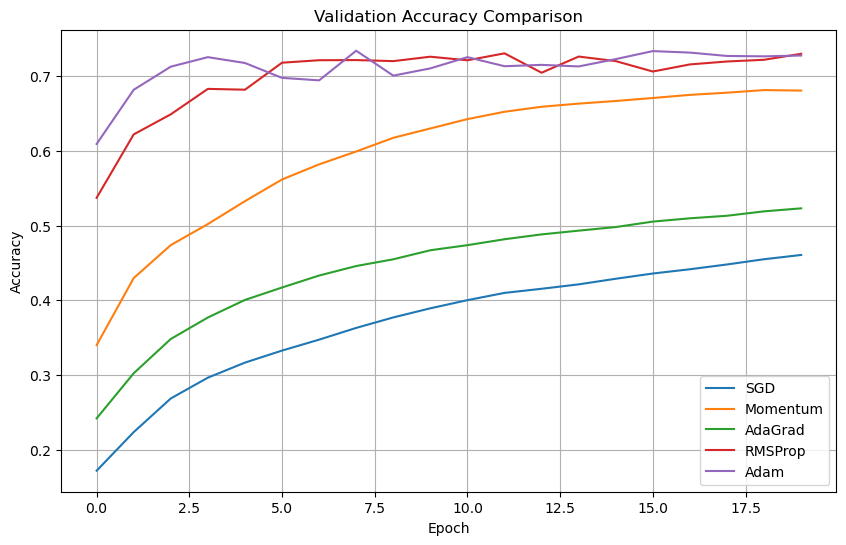

In [47]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

## 4B

In [48]:
learning_rates = {
    '0.0001': 0.0001,
    '0.001': 0.001,
    '0.01': 0.01
}
histories = []
labels = []
results = []

for name, lr in learning_rates.items():

    print(f"\nTraining with learning rate = {lr}")

    model = build_medium_model()

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=30
    )

    histories.append(history)
    labels.append(name)

    results.append({
        "Learning Rate": lr,
        "Train Loss": history.history['loss'][-1],
        "Val Loss": history.history['val_loss'][-1],
        "Test Acc": test_acc
    })


Training with learning rate = 0.0001


c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6923 | Test Loss: 1.0009 | Time: 463.7s

Training with learning rate = 0.001
Test Acc: 0.7221 | Test Loss: 2.4867 | Time: 463.8s

Training with learning rate = 0.01
Test Acc: 0.1000 | Test Loss: 2.3032 | Time: 462.1s


In [49]:
df = pd.DataFrame(results)
print(df)

   Learning Rate  Train Loss  Val Loss  Test Acc
0         0.0001    0.432290  1.003584    0.6923
1         0.0010    0.048594  2.442142    0.7221
2         0.0100    2.303370  2.303480    0.1000


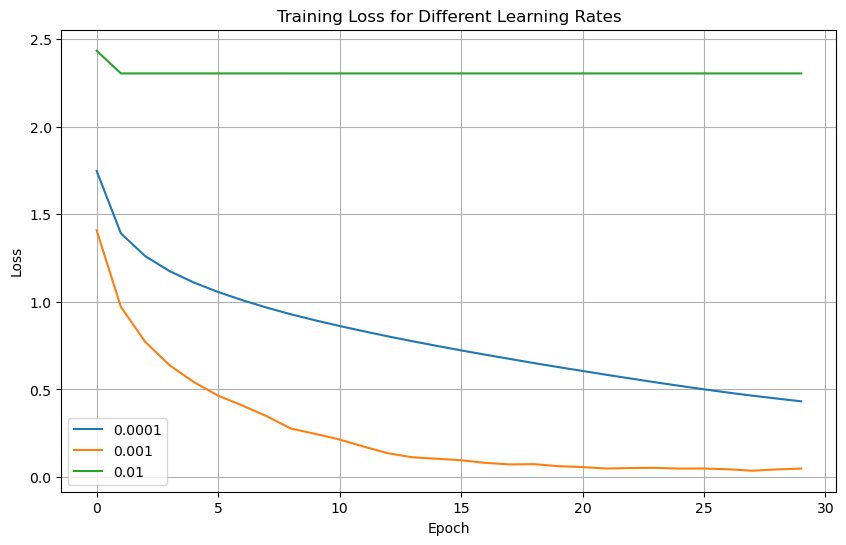

In [50]:
plot_curves(
    histories,
    labels,
    metric='loss',
    title='Training Loss for Different Learning Rates',
    ylabel='Loss'
)

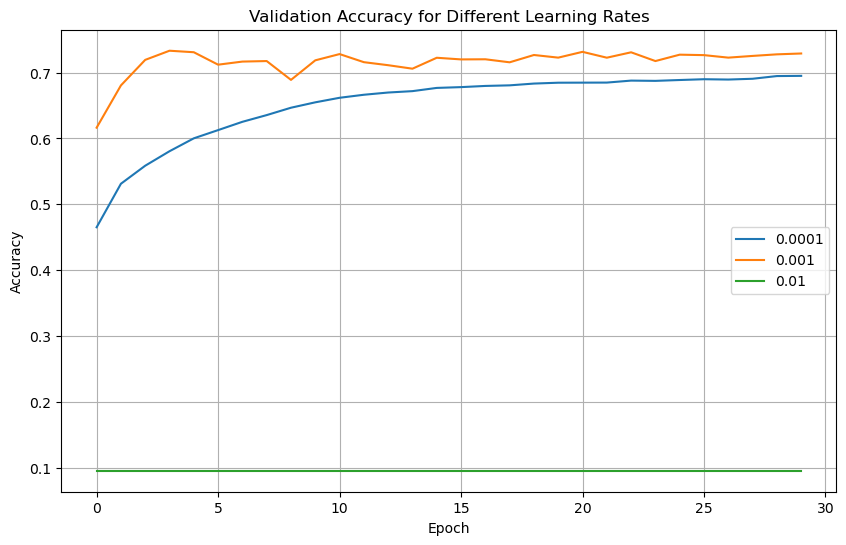

In [51]:
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy for Different Learning Rates',
    ylabel='Accuracy'
)

### 5A

### buliding model with best combination

#### chosen model settings
1- Min-Max normalization
2- large filters
3- dropout 0.5
4- Medium depth
5- RMSprob Optimizer
6- learning rate 0.001

In [62]:
import time as t
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(x_train_B)

best_model = models.Sequential([
    layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.5),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
best_model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
start = t.time()
best_model.fit(
    datagen.flow(x_train_B, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_B, to_categorical(y_val, 10)),
    epochs=50,
    verbose=0,
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)]
)
end = t.time() - start
test_loss, test_acc = best_model.evaluate(x_test_B, to_categorical(y_test, 10), verbose=0)
history_best = best_model.history

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


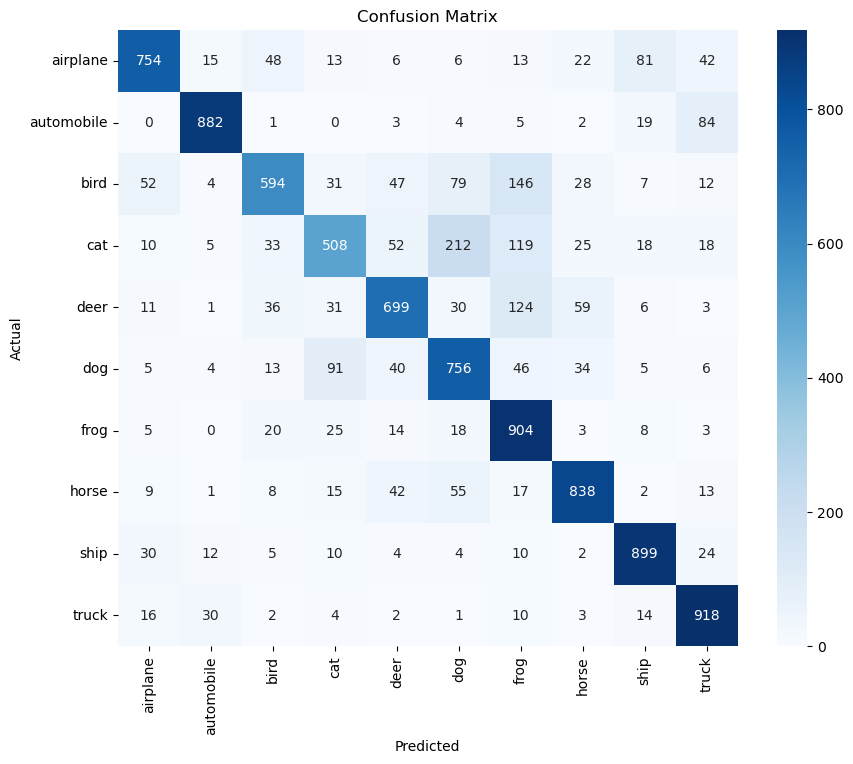

              precision    recall  f1-score   support

    airplane       0.85      0.75      0.80      1000
  automobile       0.92      0.88      0.90      1000
        bird       0.78      0.59      0.68      1000
         cat       0.70      0.51      0.59      1000
        deer       0.77      0.70      0.73      1000
         dog       0.65      0.76      0.70      1000
        frog       0.65      0.90      0.76      1000
       horse       0.82      0.84      0.83      1000
        ship       0.85      0.90      0.87      1000
       truck       0.82      0.92      0.86      1000

    accuracy                           0.78     10000
   macro avg       0.78      0.78      0.77     10000
weighted avg       0.78      0.78      0.77     10000



In [72]:
y_pred = np.argmax(best_model.predict(x_test_B), axis=1)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
report = classification_report(y_test, y_pred, target_names=CLASS_NAMES, output_dict=False)
print(report)

In [85]:
recall_scores = {}
recall_scores_dupe = {}
for i in range(10):
    recall = cm[i][i] / np.sum(cm[i]) if np.sum(cm[i]) > 0 else 0
    recall_scores[CLASS_NAMES[i]] = recall
    recall_scores_dupe[i] = recall
recall_scores = dict(sorted(recall_scores.items(), key=lambda item: item[1], reverse=False))
recall_scores_dupe = dict(sorted(recall_scores_dupe.items(), key=lambda item: item[1], reverse=False))
lowest_recall = list(recall_scores.items())[:3]
lowest_recall_dupe = list(recall_scores_dupe.items())[:3]
print("Lowest Recall Classes:")
for cls, score in lowest_recall:
    print(f"{cls}: {score:.4f}")

Lowest Recall Classes:
cat: 0.5080
bird: 0.5940
deer: 0.6990


In [86]:
misclassified_idx = np.where(y_pred != y_test.flatten())[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")
def show_misclassified(true_class, n=5):
    idx = [i for i in misclassified_idx if y_test[i] == true_class][:n]
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for ax, i in zip(axes, idx):
        ax.imshow(x_test[i].astype('uint8'))
        ax.set_title(f"True: {CLASS_NAMES[y_test[i][0]]}\nPred:{CLASS_NAMES[y_pred[i]]}")
        ax.axis('off')
    plt.suptitle(f"Misclassified '{CLASS_NAMES[true_class]}'")
    plt.tight_layout()
    plt.show()

Total misclassified: 2248 / 10000


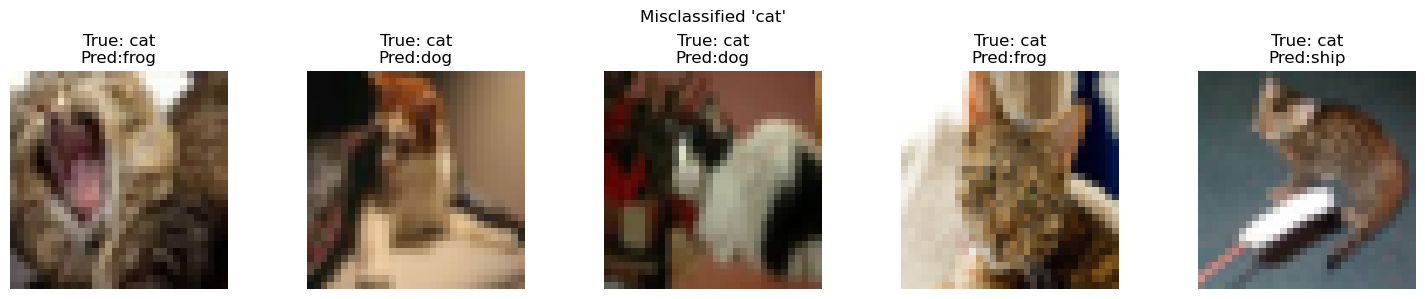

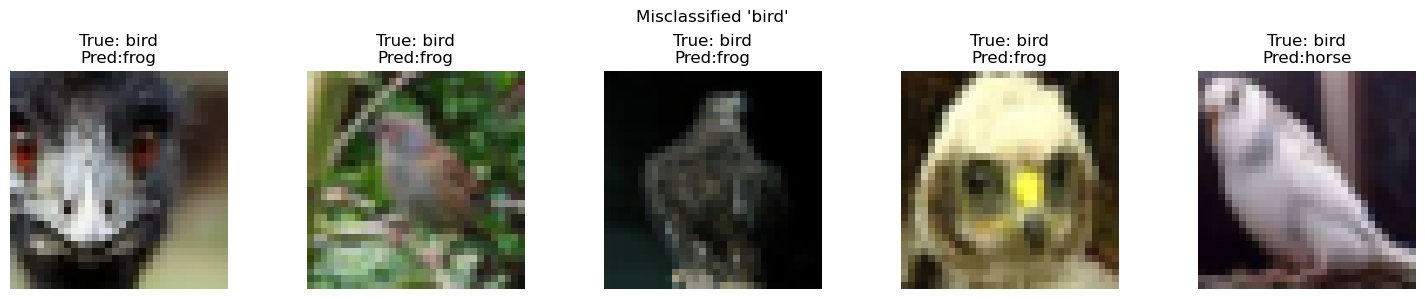

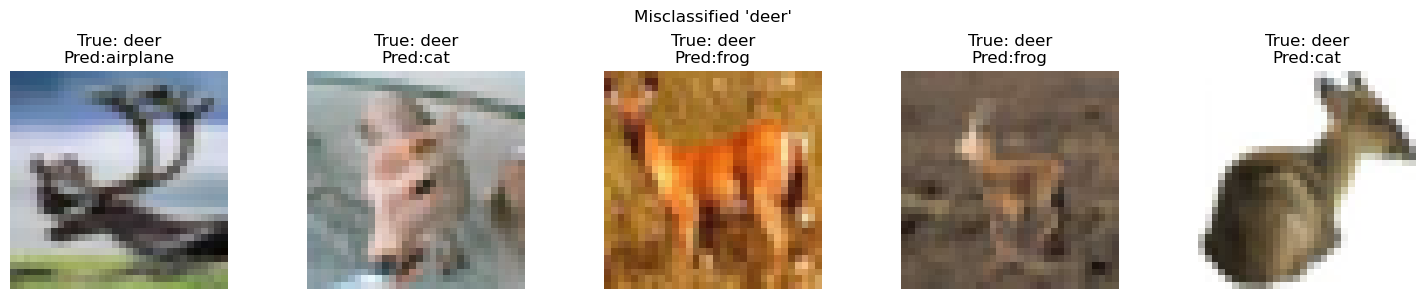

In [87]:
for cls, _ in lowest_recall_dupe:
    show_misclassified(cls)

#### these calsses get missclassified more than the other because in 32*32 resulotion they share a lot of visual similarities with the other classes like the colors of the deer and cat, also the similarity between birds and frogs in the size to image ratio which make it harder for the model to get the right predictions in such low resulotion

### 6A

### building the medium model (scratch model)

In [88]:
x_train_resized = tf.image.resize(x_train_std, (48, 48)).numpy()
x_val_resized = tf.image.resize(x_val_std, (48, 48)).numpy()
x_test_resized = tf.image.resize(x_test_std, (48, 48)).numpy()
histories = []
test_accs = []
test_losses = []
times = []
models_list = []
f1,f2,f3,f4 = models_config["Medium"]
scratch_model = models.Sequential([
    layers.Conv2D(f1, (3,3), activation='relu', padding='same', input_shape=(48, 48, 3)),
    layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(f3, (3,3), activation='relu', padding='same'),
    layers.Conv2D(f4, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
scratch_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(scratch_model)

c:\Users\zeyad\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### building the freezed vgg model

In [89]:
vgg_base = keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(48, 48, 3)
)
vgg_base.trainable = False
vgg_freezed_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
vgg_freezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(vgg_freezed_model)

### building the semifreezed vgg model with lower learning rate

In [90]:
vgg_base.trainable = True
for layer in vgg_base.layers[:-4]:
    layer.trainable = False
vgg_semifreezed_model = models.Sequential([
    vgg_base,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])
vgg_semifreezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(vgg_semifreezed_model)

### building the semifreezed vgg model with high learning rate

In [91]:
vgg_semifreezed_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
models_list.append(vgg_semifreezed_model)

In [95]:
models_list

[<Sequential name=sequential_34, built=True>,
 <Sequential name=sequential_35, built=True>,
 <Sequential name=sequential_36, built=True>,
 <Sequential name=sequential_36, built=True>]

### fitting models

In [94]:
for model in models_list:
    history, test_acc, test_loss, t = train_and_evaluate(
        model,
        x_train_resized, y_train,
        x_val_resized, y_val,
        x_test_resized, y_test,
        epochs=20,
        batch_size=128
    )
    print(f" training model: {model}")
    print(model.summary())
    histories.append(history)
    test_accs.append(test_acc)
    test_losses.append(test_loss)
    times.append(t)

Test Acc: 0.6740 | Test Loss: 2.7848 | Time: 990.5s
 training model: <Sequential name=sequential_34, built=True>


Model: "sequential_34"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_144 (Conv2D)             │ (None, 48, 48, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_145 (Conv2D)             │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_69 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_146 (Conv2D)             │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_147 (Conv2D)             │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_70 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_69 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,283,072 (27.78 MB)

 Trainable params: 2,427,690 (9.26 MB)

...

 Total params: 29,275,232 (111.68 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

 Optimizer params: 14,426,646 (55.03 MB)

None


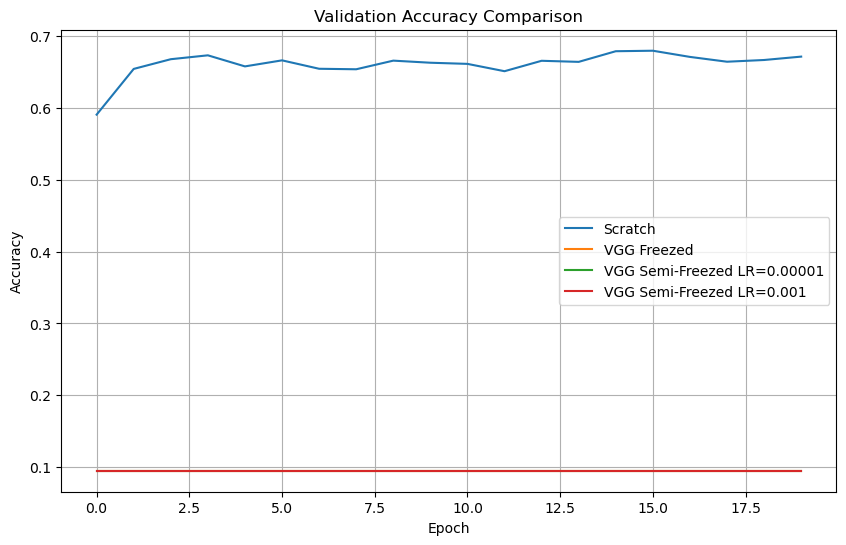

In [96]:
plot_curves(
    histories,
    ['Scratch', 'VGG Freezed', 'VGG Semi-Freezed LR=0.00001', 'VGG Semi-Freezed LR=0.001'],
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

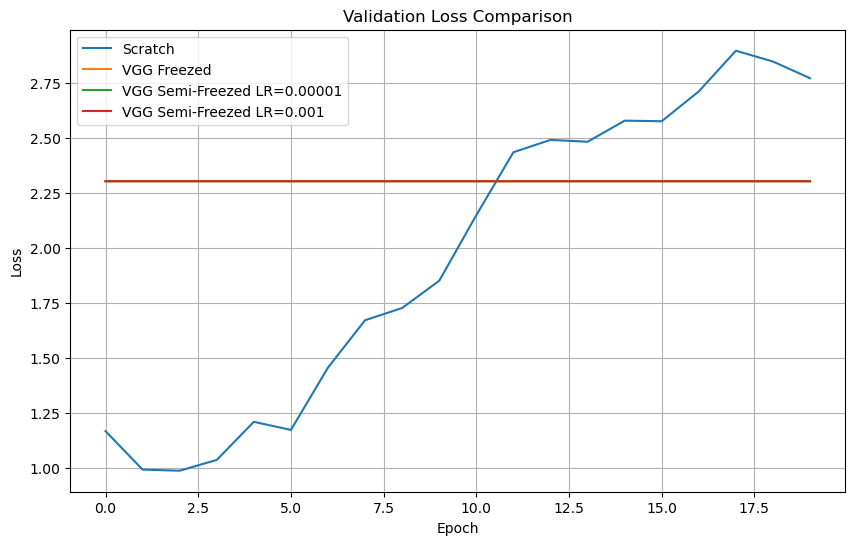

In [98]:
plot_curves(
    histories,
    ['Scratch', 'VGG Freezed', 'VGG Semi-Freezed LR=0.00001', 'VGG Semi-Freezed LR=0.001'],
    metric='val_loss',
    title='Validation Loss Comparison',
    ylabel='Loss'
)

In [99]:
# create a dataframe for number of parameters and nontrainable parameters and trainable parameters for each model
model_names = ['Scratch', 'VGG Freezed', 'VGG Semi-Freezed LR=0.00001', 'VGG Semi-Freezed LR=0.001']
params = []
for model in models_list:
    total_params = model.count_params()
    trainable_params = np.sum([tf.keras.backend.count_params(w) for w in model.trainable_weights])
    non_trainable_params = total_params - trainable_params
    params.append({
        "Model": model_names[models_list.index(model)],
        "Total Params": total_params,
        "Trainable Params": trainable_params,
        "Non-Trainable Params": non_trainable_params
    })
params_df = pd.DataFrame(params)
print(params_df)

                         Model  Total Params  Trainable Params  \
0                      Scratch       2427690           2427690   
1                  VGG Freezed      14848586           7213322   
2  VGG Semi-Freezed LR=0.00001      14848586           7213322   
3  VGG Semi-Freezed LR=0.00001      14848586           7213322   

   Non-Trainable Params  
0                     0  
1               7635264  
2               7635264  
3               7635264  
